In [20]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
data = pd.read_csv('final_screen (1).xls')

In [22]:
data.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Week_Type,Usage_Quality,Device_Mobility,Health_Impact_Count,Health_Severity,Screen_Time_Range
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Mid_Teen (14-16),Weekday,Bad,Portable,2,Mild Risk,medium
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Early_Teen (11-13),Weekend,Bad,Portable,1,Mild Risk,medium
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late_Teen (17-18),Weekday,Bad,Stationary,1,Mild Risk,medium
3,15,Female,1.21,Laptop,False,0.39,No Issues,Urban,Mid_Teen (14-16),Weekday,Bad,Portable,0,No Risk,low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early_Teen (11-13),Weekend,Bad,Portable,2,Mild Risk,medium


In [23]:
cohort_counts = data.groupby(['Age_Band', 'Primary_Device']).size().reset_index(name='Count')


top_cohorts = cohort_counts.sort_values(by='Count', ascending=False)

print(top_cohorts)

              Age_Band Primary_Device  Count
1   Early_Teen (11-13)     Smartphone   1304
9     Mid_Teen (14-16)     Smartphone   1301
12     Pre_Teen (8-10)     Smartphone   1050
13     Pre_Teen (8-10)             TV   1037
5    Late_Teen (17-18)     Smartphone    885
0   Early_Teen (11-13)         Laptop    552
14     Pre_Teen (8-10)         Tablet    551
10    Mid_Teen (14-16)             TV    543
8     Mid_Teen (14-16)         Laptop    539
2   Early_Teen (11-13)             TV    532
6    Late_Teen (17-18)             TV    366
4    Late_Teen (17-18)         Laptop    340
3   Early_Teen (11-13)         Tablet    252
11    Mid_Teen (14-16)         Tablet    250
7    Late_Teen (17-18)         Tablet    166


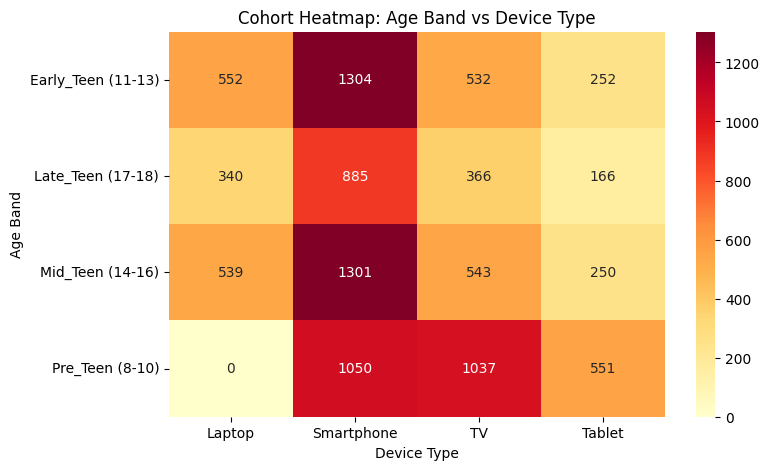

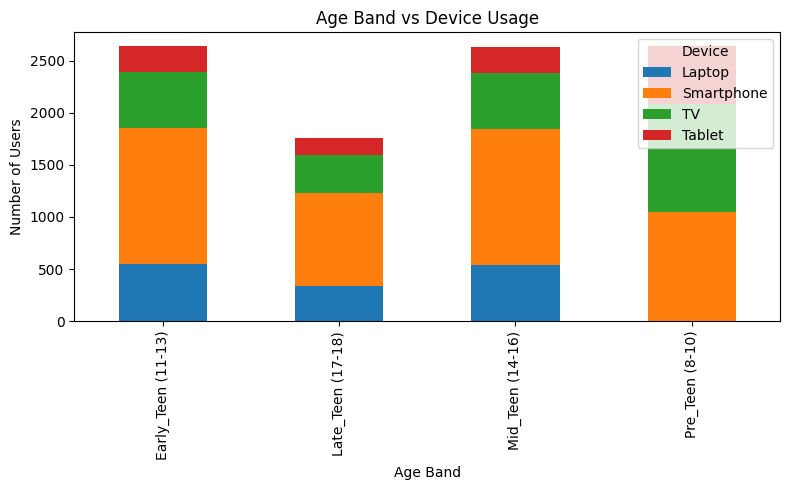

In [37]:
pivot_table = data.pivot_table(
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='size',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlOrRd")

plt.title("Cohort Heatmap: Age Band vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()



pivot1 = cohort_counts.pivot(index='Age_Band', columns='Primary_Device', values='Count')

# stacked bar chart
pivot1.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Age Band vs Device Usage")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.legend(title="Device")
plt.tight_layout()
plt.show()

In [25]:
cohort1 = data.groupby(['Age_Band','Week_Type']).size().reset_index(name='Count')
print(cohort1.sort_values(by='Count', ascending=False))

             Age_Band Week_Type  Count
6     Pre_Teen (8-10)   Weekday   1524
1  Early_Teen (11-13)   Weekend   1411
5    Mid_Teen (14-16)   Weekend   1369
4    Mid_Teen (14-16)   Weekday   1264
0  Early_Teen (11-13)   Weekday   1229
7     Pre_Teen (8-10)   Weekend   1114
3   Late_Teen (17-18)   Weekend    930
2   Late_Teen (17-18)   Weekday    827


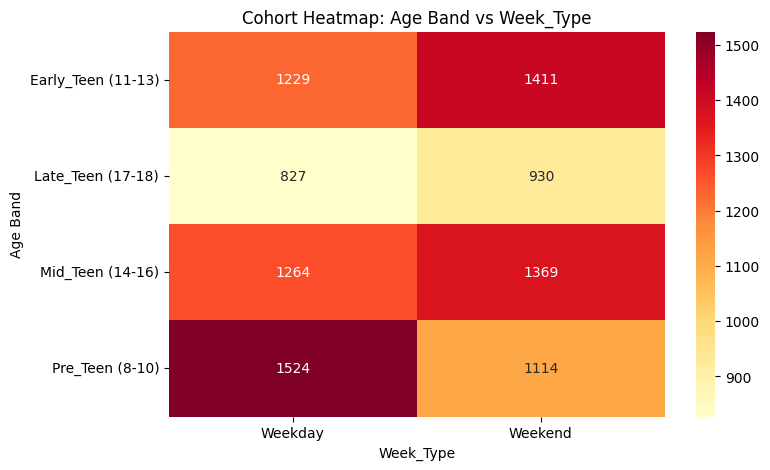

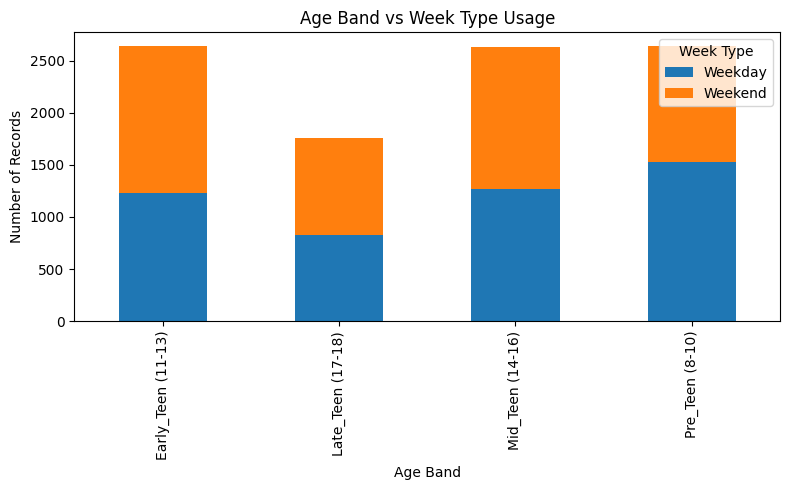

In [38]:
pivot_table = data.pivot_table(
    index='Age_Band',
    columns='Week_Type',
    aggfunc='size',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlOrRd")

plt.title("Cohort Heatmap: Age Band vs Week_Type")
plt.xlabel("Week_Type")
plt.ylabel("Age Band")

plt.show()



pivot2 = cohort1.pivot(index='Age_Band', columns='Week_Type', values='Count')

pivot2.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Age Band vs Week Type Usage")
plt.xlabel("Age Band")
plt.ylabel("Number of Records")
plt.legend(title="Week Type")

plt.tight_layout()
plt.show()

In [27]:
df = data.copy()


In [29]:
df['Health_Impacts'] = df['Health_Impacts'].str.split(',')

In [33]:
df_exploded = df.explode('Health_Impacts')
df_exploded['Health_Impacts'] = df_exploded['Health_Impacts'].str.strip()

In [35]:
cohort = df_exploded.groupby(
    ['Primary_Device','Health_Impacts']
).size().reset_index(name='Count')

print(cohort.sort_values(by='Count', ascending=False))

   Primary_Device Health_Impacts  Count
9      Smartphone     Poor Sleep   2303
7      Smartphone      No Issues   1445
14             TV     Poor Sleep   1178
6      Smartphone     Eye Strain   1172
12             TV      No Issues    897
4          Laptop     Poor Sleep    790
5      Smartphone        Anxiety    743
8      Smartphone   Obesity Risk    612
19         Tablet     Poor Sleep    591
11             TV     Eye Strain    546
17         Tablet      No Issues    459
1          Laptop     Eye Strain    396
10             TV        Anxiety    389
2          Laptop      No Issues    379
13             TV   Obesity Risk    287
0          Laptop        Anxiety    279
16         Tablet     Eye Strain    267
15         Tablet        Anxiety    193
3          Laptop   Obesity Risk    175
18         Tablet   Obesity Risk    143


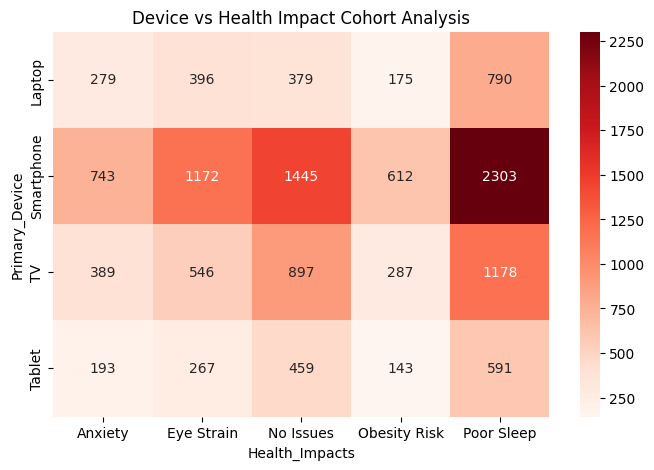

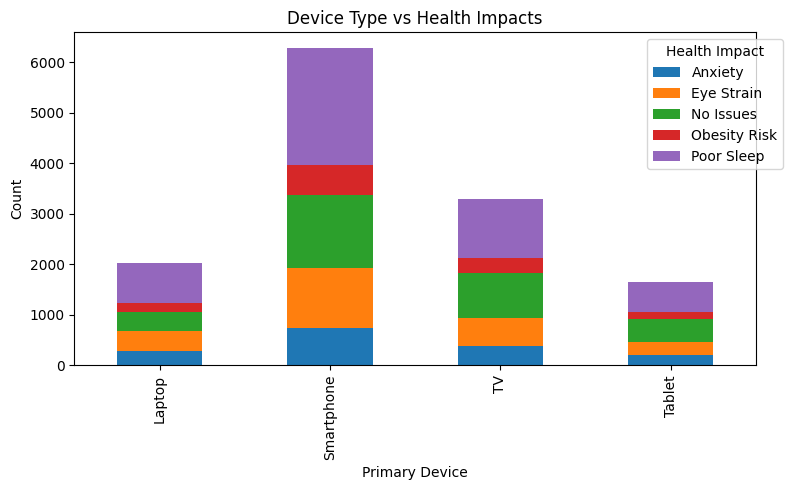

In [39]:
pivot = df_exploded.pivot_table(
    index='Primary_Device',
    columns='Health_Impacts',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds")

plt.title("Device vs Health Impact Cohort Analysis")
plt.show()



pivot3 = cohort.pivot(index='Primary_Device', columns='Health_Impacts', values='Count')

pivot3.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Device Type vs Health Impacts")
plt.xlabel("Primary Device")
plt.ylabel("Count")
plt.legend(title="Health Impact", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

In [40]:
location_cohort = data.groupby(
    ['Urban_or_Rural','Primary_Device']
).size().reset_index(name='Count')

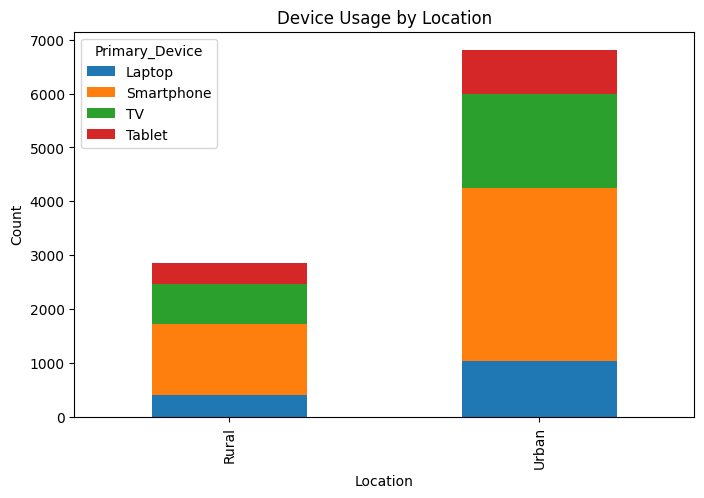

In [41]:
pivot = location_cohort.pivot(index='Urban_or_Rural', columns='Primary_Device', values='Count')

pivot.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Device Usage by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

In [ ]:
# week 6

<Axes: xlabel='Age_Band'>

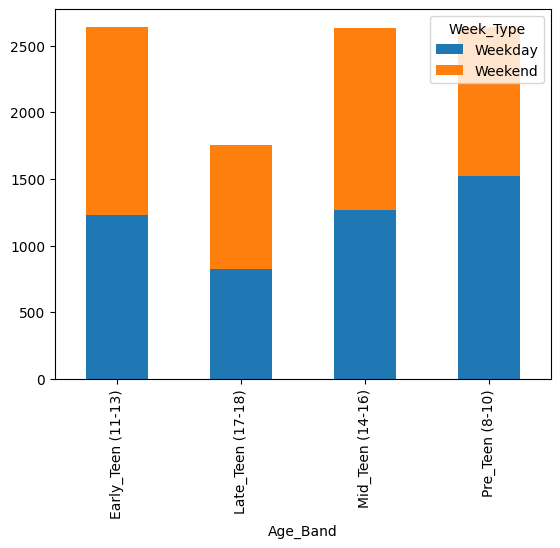

In [45]:
cohort = data.groupby(['Age_Band','Week_Type']).size().reset_index(name='Count')

pivot = cohort.pivot(index='Age_Band', columns='Week_Type', values='Count')

pivot.plot(kind='bar', stacked=True)

<Axes: xlabel='Primary_Device'>

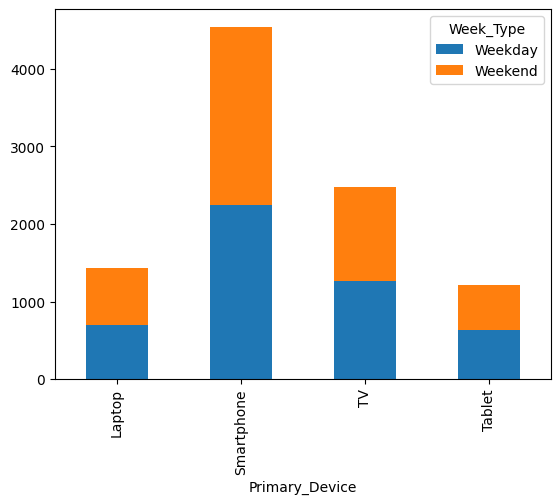

In [44]:
cohort = data.groupby(['Primary_Device','Week_Type']).size().reset_index(name='Count')

pivot = cohort.pivot(index='Primary_Device', columns='Week_Type', values='Count')

pivot.plot(kind='bar', stacked=True)

<Axes: xlabel='Screen_Time_Range'>

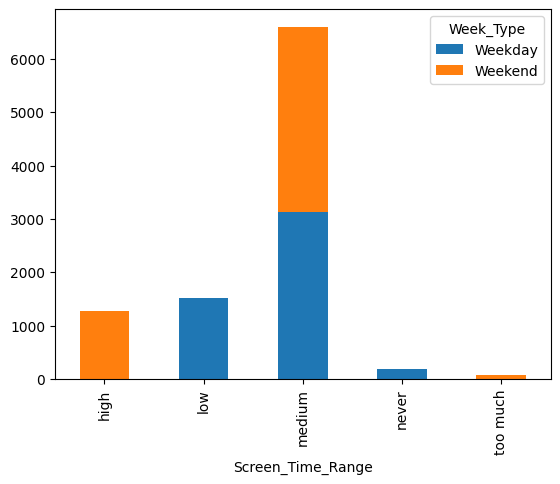

In [47]:
cohort = data.groupby(['Screen_Time_Range','Week_Type']).size().reset_index(name='Count')
pivot = cohort.pivot(index='Screen_Time_Range', columns='Week_Type', values='Count')

pivot.plot(kind='bar', stacked=True)